<a href="https://colab.research.google.com/github/Ravi-attada/Mental-Health-Issue-Prediction/blob/main/code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 51 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            10000 non-null  int64  
 1   Gender                         10000 non-null  object 
 2   Country                        10000 non-null  object 
 3   Education                      10000 non-null  object 
 4   Marital_Status                 10000 non-null  object 
 5   Income_Level                   10000 non-null  object 
 6   Employment_Status              10000 non-null  object 
 7   Work_Hours_Per_Week            10000 non-null  int64  
 8   Remote_Work                    10000 non-null  object 
 9   Job_Satisfaction               10000 non-null  int64  
 10  Work_Stress_Level              10000 non-null  int64  
 11  Work_Life_Balance              10000 non-null  int64  
 12  Ever_Bullied_At_Work           10000 non-null  

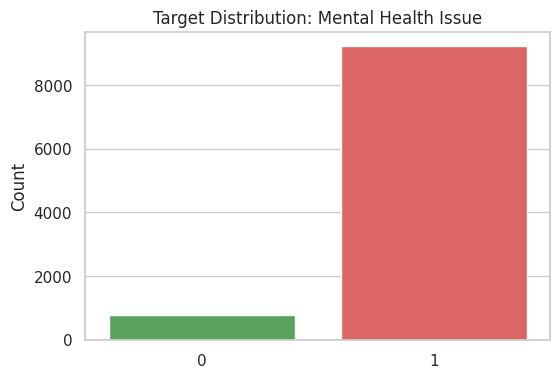

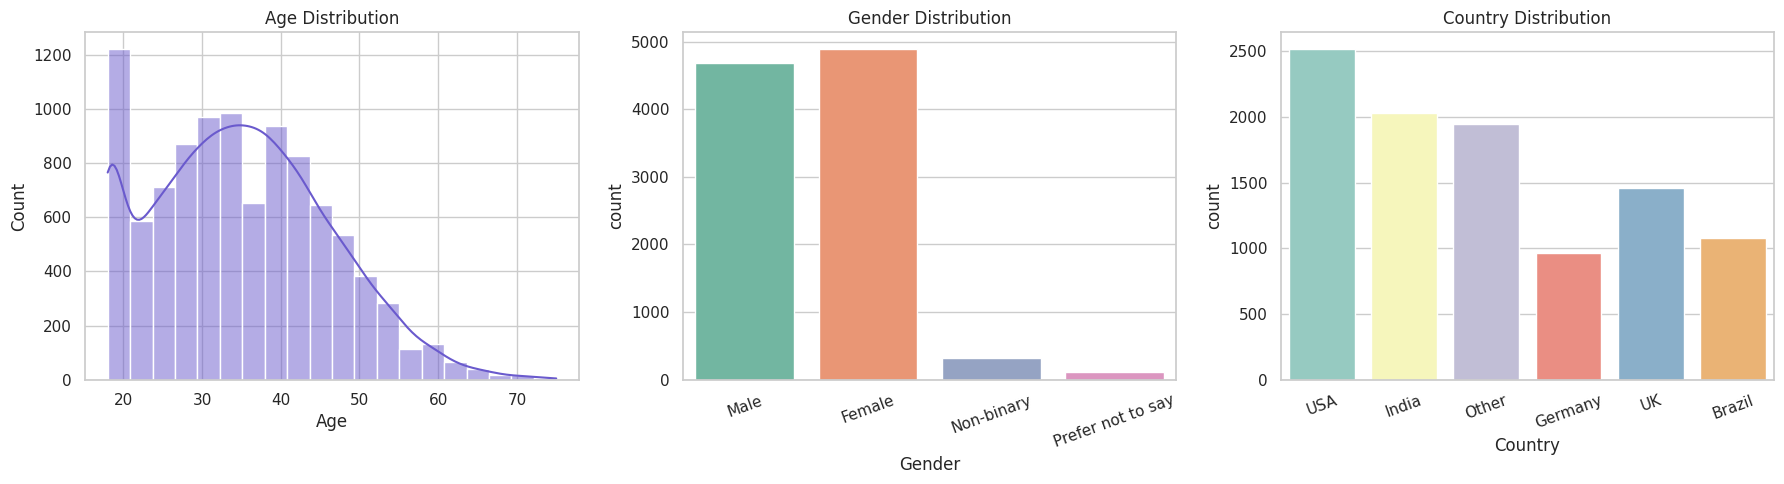

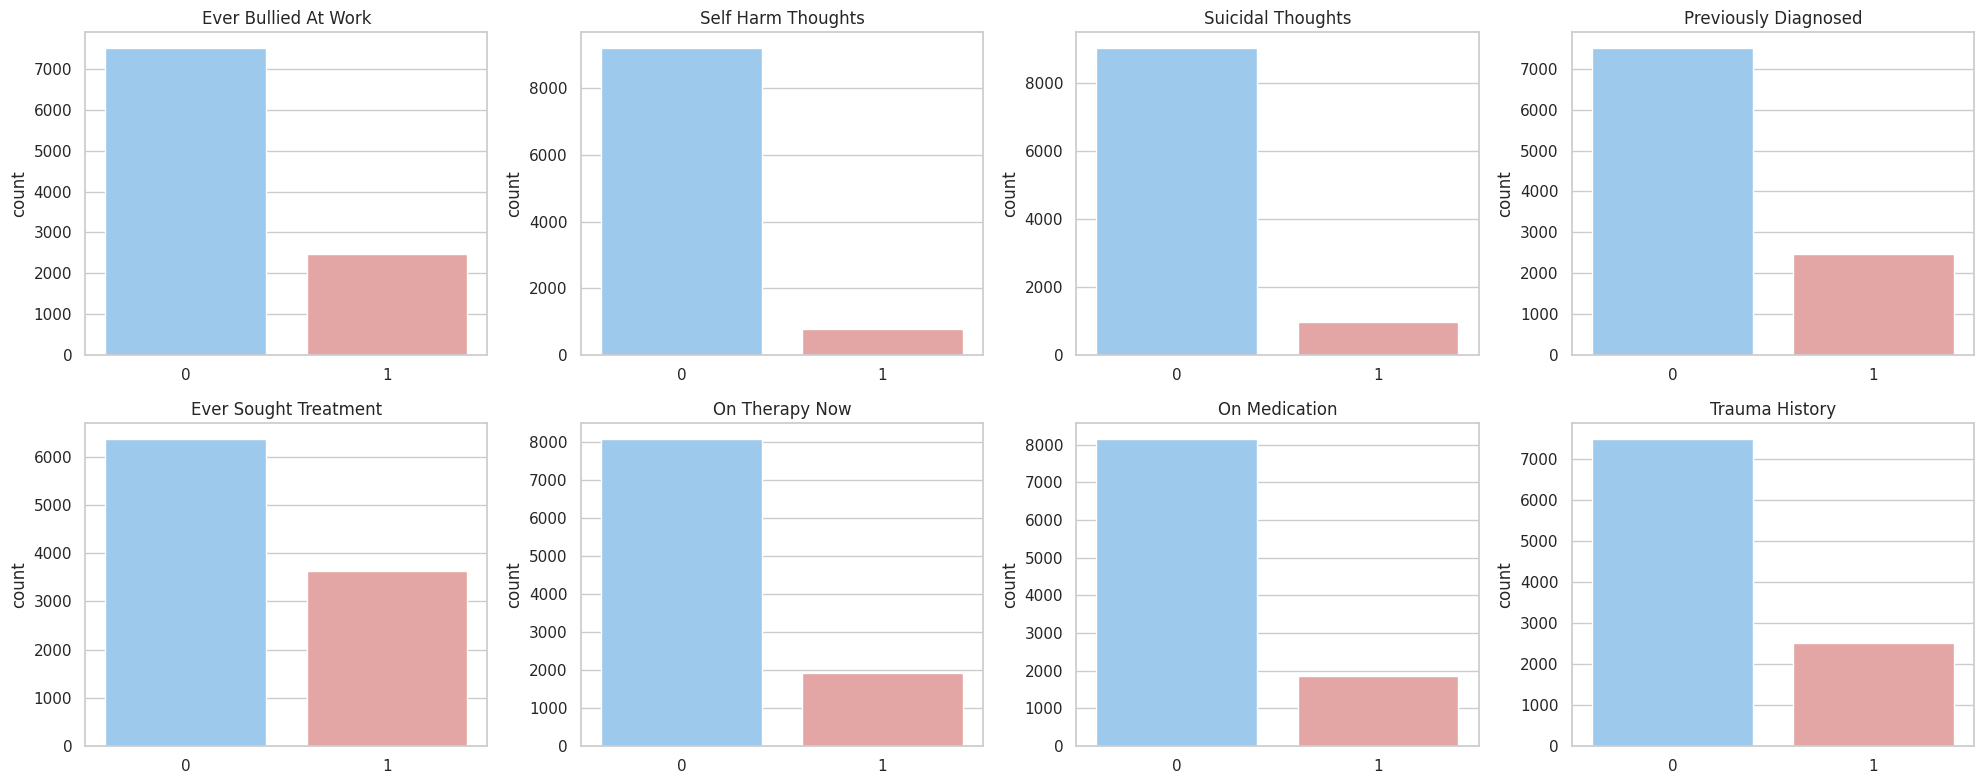

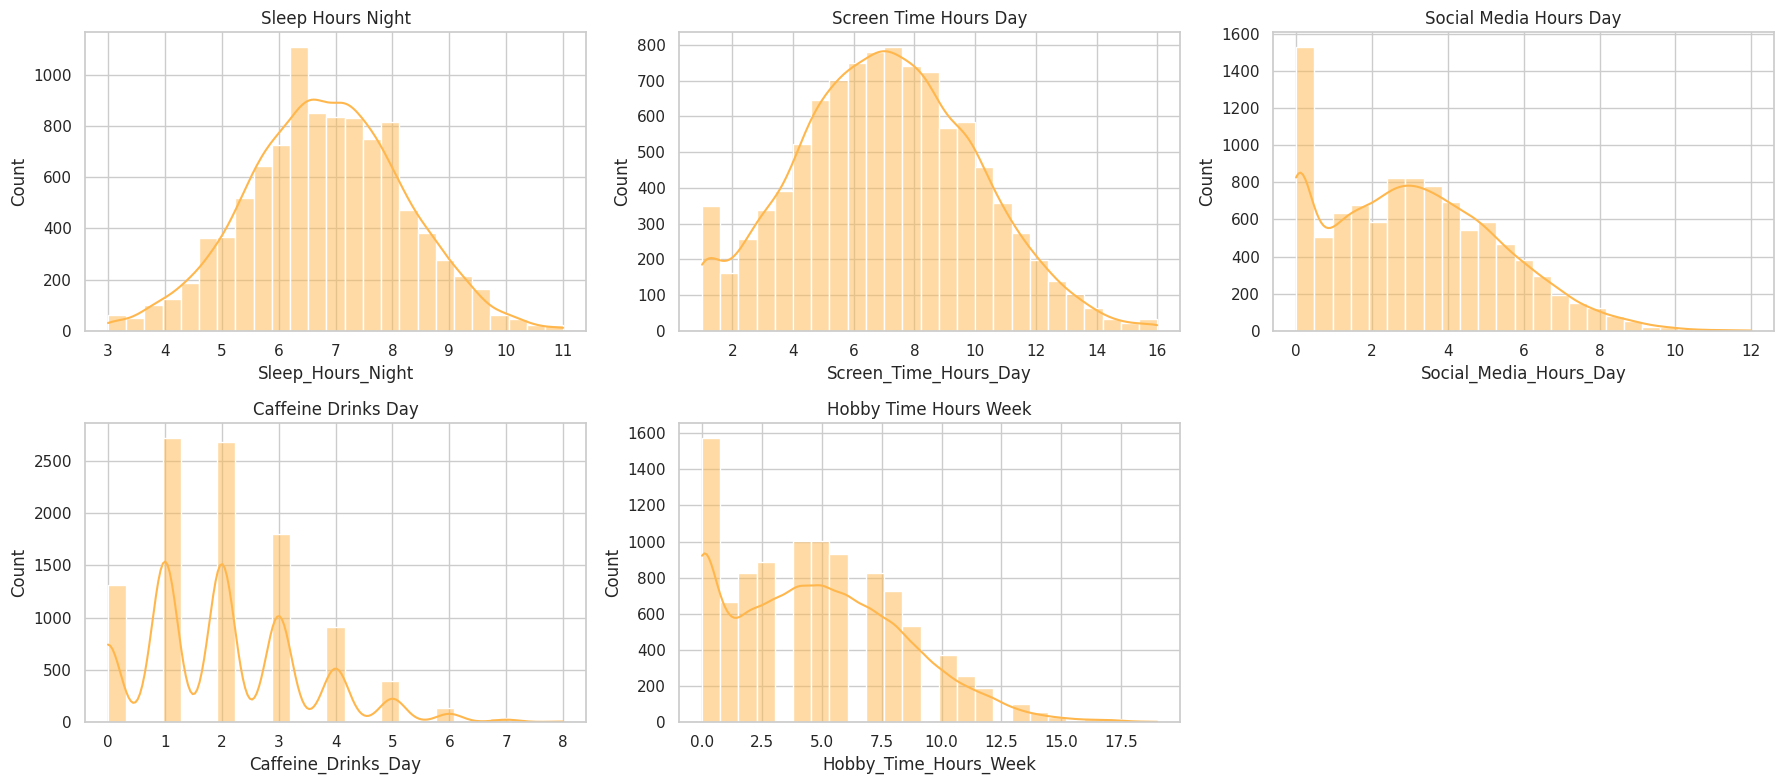

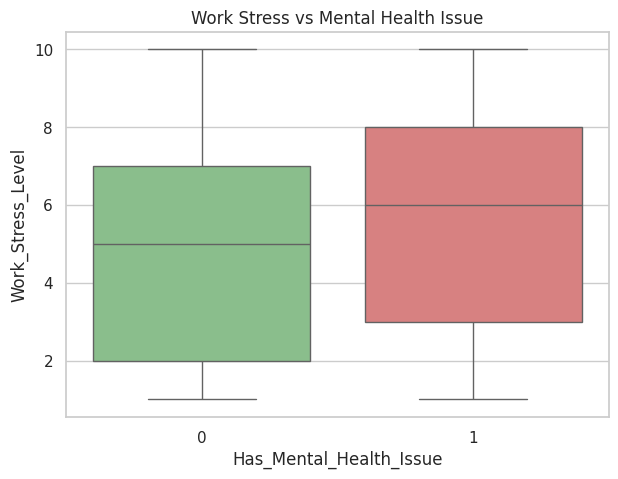

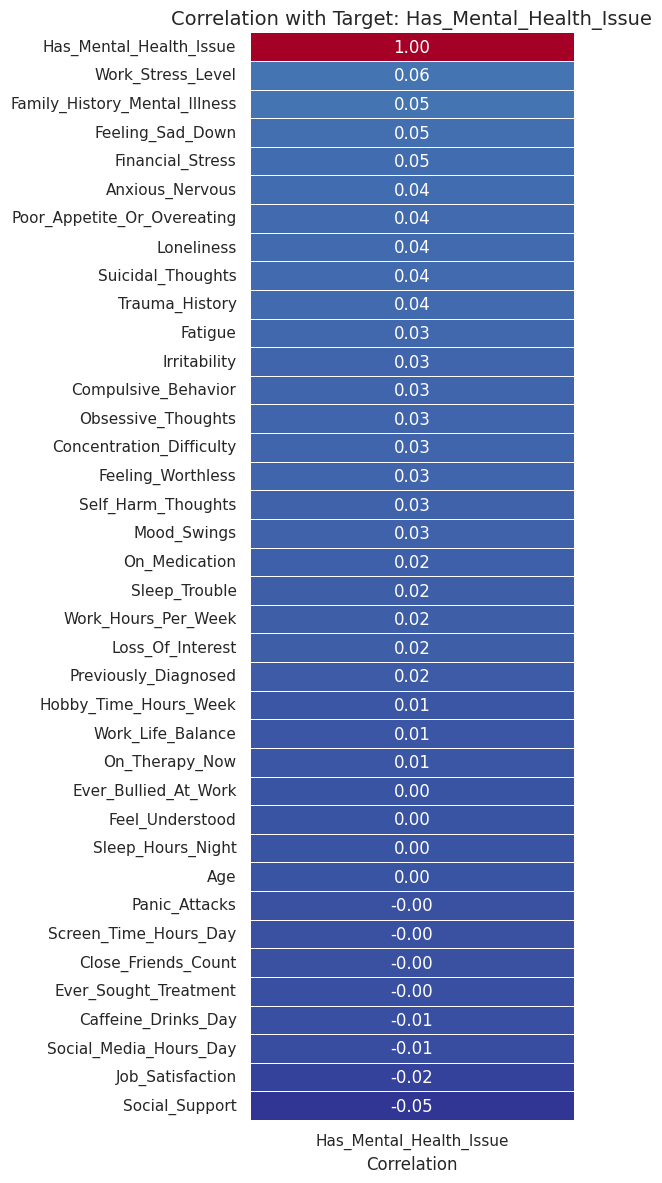

Train shape :  (7500, 50)
Test shape :  (2500, 50)
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       193
           1       0.92      1.00      0.96      2307

    accuracy                           0.92      2500
   macro avg       0.46      0.50      0.48      2500
weighted avg       0.85      0.92      0.89      2500

[[   0  193]
 [   0 2307]]


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
df = pd.read_csv("/content/mental_health.csv")
df.head()
df.isnull().sum().sum()
df.info()

numeric_cols = df.select_dtypes(include="number").columns
object_cols = df.select_dtypes(include="object").columns

print(" NUMERIC COLUMNS")
print("-" * 50)

for col in numeric_cols:
    nunique = df[col].nunique()
    print(f"\n {col}")
    print(f"nunique: {nunique}")

    if nunique < 15:
        print("unique values:", df[col].unique())

print("\n" + "=" * 60)

print(" OBJECT COLUMNS")
print("-" * 50)

for col in object_cols:
    nunique = df[col].nunique()
    print(f"\n {col}")
    print(f"nunique: {nunique}")

    if nunique < 15:
        print("unique values:", df[col].unique())
numeric_cols = df.select_dtypes(include="number").columns
object_cols = df.select_dtypes(include="object").columns

print(" NUMERIC COLUMNS")
print("-" * 50)

for col in numeric_cols:
    nunique = df[col].nunique()
    print(f"\n {col}")
    print(f"nunique: {nunique}")

    if nunique < 15:
        print("unique values:", df[col].unique())

print("\n" + "=" * 60)

print(" OBJECT COLUMNS")
print("-" * 50)

for col in object_cols:
    nunique = df[col].nunique()
    print(f"\n {col}")
    print(f"nunique: {nunique}")

    if nunique < 15:
        print("unique values:", df[col].unique())
sns.set_theme(style="whitegrid", palette="muted")

plt.figure(figsize=(6,4))
sns.countplot(
    data=df,
    x="Has_Mental_Health_Issue",
    palette=["#4CAF50", "#EF5350"]
)
plt.title("Target Distribution: Mental Health Issue")
plt.xlabel("")
plt.ylabel("Count")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.histplot(df["Age"], bins=20, kde=True, color="#6A5ACD", ax=axes[0])
axes[0].set_title("Age Distribution")

sns.countplot(data=df, x="Gender", palette="Set2", ax=axes[1])
axes[1].set_title("Gender Distribution")
axes[1].tick_params(axis="x", rotation=20)

sns.countplot(data=df, x="Country", palette="Set3", ax=axes[2])
axes[2].set_title("Country Distribution")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

binary_cols = [
    "Ever_Bullied_At_Work", "Self_Harm_Thoughts", "Suicidal_Thoughts",
    "Previously_Diagnosed", "Ever_Sought_Treatment",
    "On_Therapy_Now", "On_Medication", "Trauma_History"
]

fig, axes = plt.subplots(2, 4, figsize=(20,8))
axes = axes.flatten()

for ax, col in zip(axes, binary_cols):
    sns.countplot(
        data=df,
        x=col,
        palette=["#90CAF9", "#EF9A9A"],
        ax=ax
    )
    ax.set_title(col.replace("_", " "))
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

life_cols = [
    "Sleep_Hours_Night",
    "Screen_Time_Hours_Day",
    "Social_Media_Hours_Day",
    "Caffeine_Drinks_Day",
    "Hobby_Time_Hours_Week"
]

fig, axes = plt.subplots(2, 3, figsize=(18,8))
axes = axes.flatten()

for ax, col in zip(axes, life_cols):
    sns.histplot(
        df[col],
        bins=25,
        kde=True,
        color="#FFB74D",
        ax=ax
    )
    ax.set_title(col.replace("_", " "))

axes[-1].axis("off")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
sns.boxplot(
    data=df,
    x="Has_Mental_Health_Issue",
    y="Work_Stress_Level",
    palette=["#81C784", "#E57373"]
)
plt.title("Work Stress vs Mental Health Issue")
plt.show()

numeric_df = df.select_dtypes(include="number")
corr_target = (numeric_df.corr()[["Has_Mental_Health_Issue"]].sort_values(by="Has_Mental_Health_Issue", ascending=False))

plt.figure(figsize=(6, 12))

sns.heatmap(
    corr_target,
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",
    linewidths=0.5,
    cbar=False
)

plt.title("Correlation with Target: Has_Mental_Health_Issue", fontsize=14)
plt.ylabel("")
plt.xlabel("Correlation")
plt.tight_layout()
plt.show()

X = df.drop("Has_Mental_Health_Issue", axis=1)
y = df["Has_Mental_Health_Issue"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print("Train shape : ", X_train.shape)
print("Test shape : ", X_test.shape)

numeric_cols = X.select_dtypes(include="number").columns
categorical_cols = X.select_dtypes(include="object").columns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)
    ]
)

from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier

feature_selector = SelectFromModel(
    estimator=RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),
    threshold="median"
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline

model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("feature_selection", feature_selector),
    ("classifier", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])
model.fit(X_train, y_train)

from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

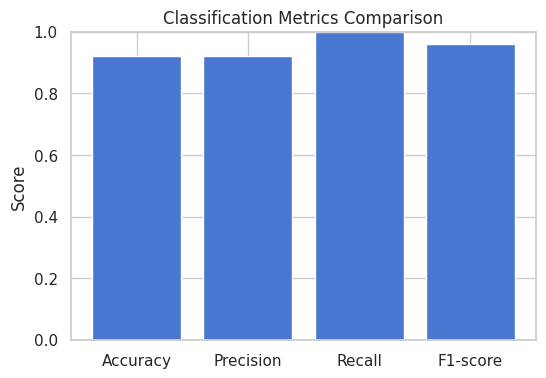

In [ ]:
import matplotlib.pyplot as plt

metrics = ["Accuracy","Precision","Recall","F1-score"]
values = [0.9228,0.9228,1.0,0.9598]

plt.figure(figsize=(6,4))
plt.bar(metrics,values)
plt.title("Classification Metrics Comparison")
plt.ylabel("Score")
plt.ylim(0,1)
plt.show()

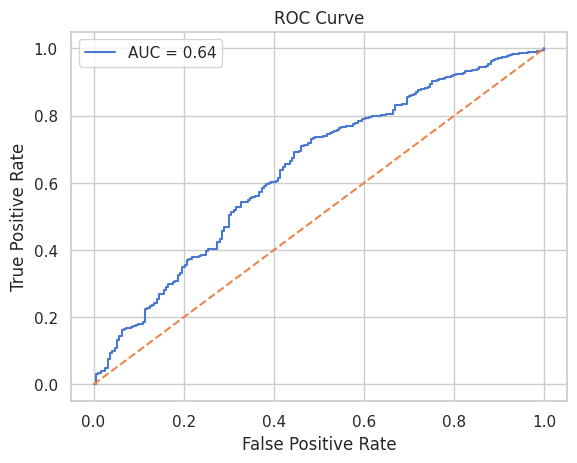

In [ ]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:,1]

fpr,tpr,_ = roc_curve(y_test,y_prob)
roc_auc = auc(fpr,tpr)

plt.figure()
plt.plot(fpr,tpr,label="AUC = %0.2f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

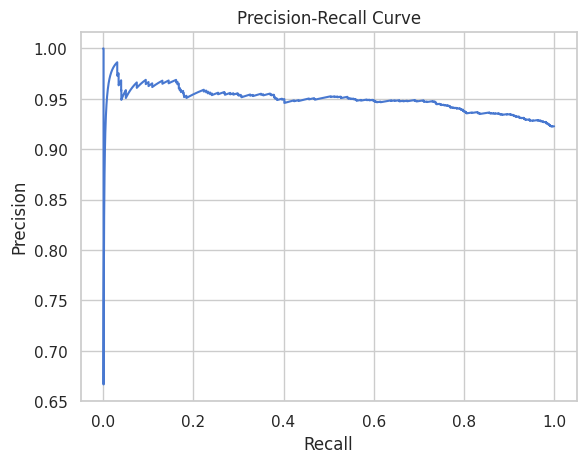

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.plot(recall,precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

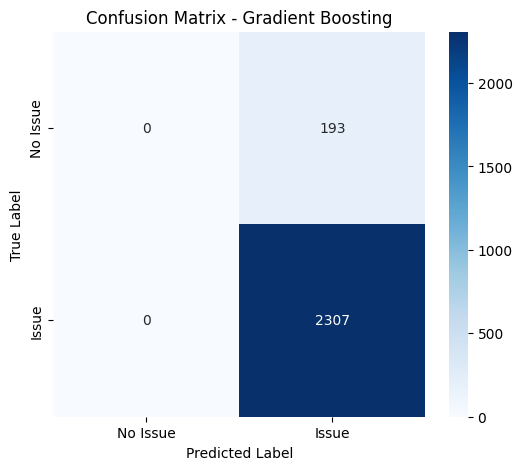

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Your actual values
cm = [[0, 193],
      [0, 2307]]

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Issue', 'Issue'],
            yticklabels=['No Issue', 'Issue'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Gradient Boosting')
plt.show()